In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import pandas as pd
import numpy as np
np.seterr(all='ignore')
import lightgbm as lgb
from pathlib import Path
import os
from typing import List, Tuple
import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL, function_future.date_selection as DS
import function_future.trading_visualization as TV
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import re


In [3]:
symbol = 'AO'
train_label = 5
train_end_date = '2025-07-01'

folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

rtn_mul = 1
config_loader = DL.InstrumentConfig()
config_loader.get_instrument_config(symbol)

{'symbol': 'AO',
 'contract_multiplier': 20,
 'price_tick': 1,
 'margin_rate': 0.11,
 'fee': 0.0001,
 'fee_way': 'rate',
 'fee_comment': '无',
 'trading_hours': ['09:00-11:30', '13:30-15:00', '21:00-01:00'],
 'light': 1,
 'night': 1,
 'exchange': 'shfe',
 'name': '氧化铝'}

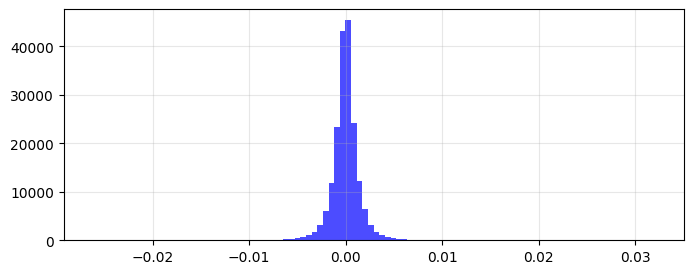


Fold 1/5
Fold 1 验证集日期范围: 2023-06-19 09:11:00 至 2023-11-13 23:22:00
Fold 1 训练集样本数: 154269, 验证集样本数: 38568
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.926811
[200]	valid_0's l2: 0.926548
[300]	valid_0's l2: 0.926352
[400]	valid_0's l2: 0.926187
[500]	valid_0's l2: 0.926068
[600]	valid_0's l2: 0.925965
[700]	valid_0's l2: 0.925851
[800]	valid_0's l2: 0.925772
[900]	valid_0's l2: 0.925712
[1000]	valid_0's l2: 0.925677
[1100]	valid_0's l2: 0.925619
[1200]	valid_0's l2: 0.925585
[1300]	valid_0's l2: 0.925587
[1400]	valid_0's l2: 0.92558
[1500]	valid_0's l2: 0.925525
[1600]	valid_0's l2: 0.925473
[1700]	valid_0's l2: 0.925402
[1800]	valid_0's l2: 0.925355
[1900]	valid_0's l2: 0.925292
[2000]	valid_0's l2: 0.925233
[2100]	valid_0's l2: 0.925227
[2200]	valid_0's l2: 0.925174
[2300]	valid_0's l2: 0.925099
[2400]	valid_0's l2: 0.925024
[2500]	valid_0's l2: 0.924963
[2600]	valid_0's l2: 0.924921
[2700]	valid_0's l2: 0.924923
[2800]	valid_0's l2: 0.924923
[29

<Figure size 1000x600 with 0 Axes>

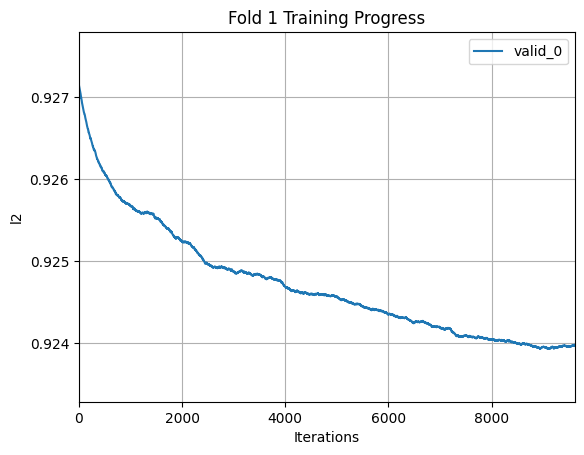

valid ic: 0.06056859151997632
模型最佳迭代次数 = 9113

Fold 2/5
Fold 2 验证集日期范围: 2023-11-13 23:23:00 至 2024-04-10 14:36:00
Fold 2 训练集样本数: 154269, 验证集样本数: 38568
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.952814
[200]	valid_0's l2: 0.952379
[300]	valid_0's l2: 0.952046
[400]	valid_0's l2: 0.951769
[500]	valid_0's l2: 0.95148
[600]	valid_0's l2: 0.951244
[700]	valid_0's l2: 0.951083
[800]	valid_0's l2: 0.950969
[900]	valid_0's l2: 0.950839
[1000]	valid_0's l2: 0.950696
[1100]	valid_0's l2: 0.950595
[1200]	valid_0's l2: 0.950511
[1300]	valid_0's l2: 0.950442
[1400]	valid_0's l2: 0.950353
[1500]	valid_0's l2: 0.950327
[1600]	valid_0's l2: 0.950248
[1700]	valid_0's l2: 0.950223
[1800]	valid_0's l2: 0.950216
[1900]	valid_0's l2: 0.950197
[2000]	valid_0's l2: 0.950222
[2100]	valid_0's l2: 0.950241
[2200]	valid_0's l2: 0.950277
[2300]	valid_0's l2: 0.950303
[2400]	valid_0's l2: 0.95037
Early stopping, best iteration is:
[1915]	valid_0's l2: 0.950193


<Figure size 1000x600 with 0 Axes>

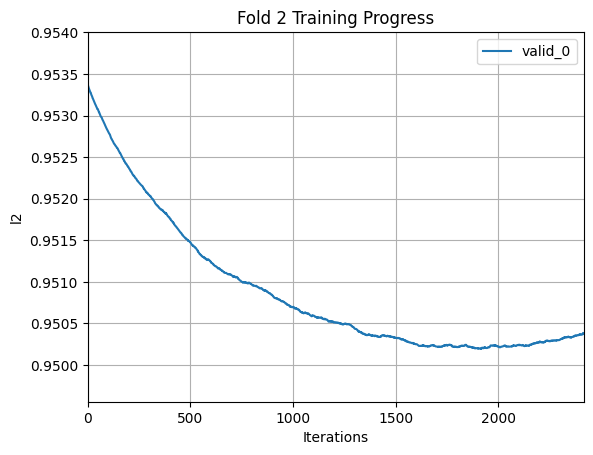

valid ic: 0.06497105412684544
模型最佳迭代次数 = 1915

Fold 3/5
Fold 3 验证集日期范围: 2024-04-10 14:37:00 至 2024-08-30 13:41:00
Fold 3 训练集样本数: 154270, 验证集样本数: 38567
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.986244
[200]	valid_0's l2: 0.985884
[300]	valid_0's l2: 0.985639
[400]	valid_0's l2: 0.985474
[500]	valid_0's l2: 0.985314
[600]	valid_0's l2: 0.985263
[700]	valid_0's l2: 0.985209
[800]	valid_0's l2: 0.985167
[900]	valid_0's l2: 0.985126
[1000]	valid_0's l2: 0.9851
[1100]	valid_0's l2: 0.985096
[1200]	valid_0's l2: 0.985124
[1300]	valid_0's l2: 0.985134
[1400]	valid_0's l2: 0.98513
[1500]	valid_0's l2: 0.985132
Early stopping, best iteration is:
[1090]	valid_0's l2: 0.985074


<Figure size 1000x600 with 0 Axes>

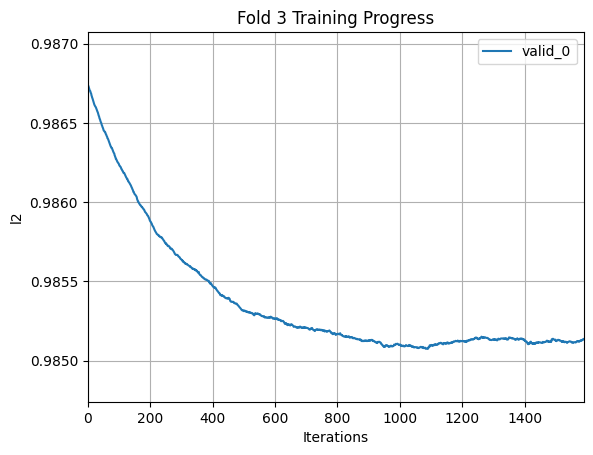

valid ic: 0.04418501890181443
模型最佳迭代次数 = 1090

Fold 4/5
Fold 4 验证集日期范围: 2024-08-30 13:42:00 至 2025-02-06 14:24:00
Fold 4 训练集样本数: 154270, 验证集样本数: 38567
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.980339
[200]	valid_0's l2: 0.979884
[300]	valid_0's l2: 0.979575
[400]	valid_0's l2: 0.979384
[500]	valid_0's l2: 0.979178
[600]	valid_0's l2: 0.979087
[700]	valid_0's l2: 0.978956
[800]	valid_0's l2: 0.97901
[900]	valid_0's l2: 0.979
[1000]	valid_0's l2: 0.979065
[1100]	valid_0's l2: 0.979077
[1200]	valid_0's l2: 0.979048
Early stopping, best iteration is:
[745]	valid_0's l2: 0.978906


<Figure size 1000x600 with 0 Axes>

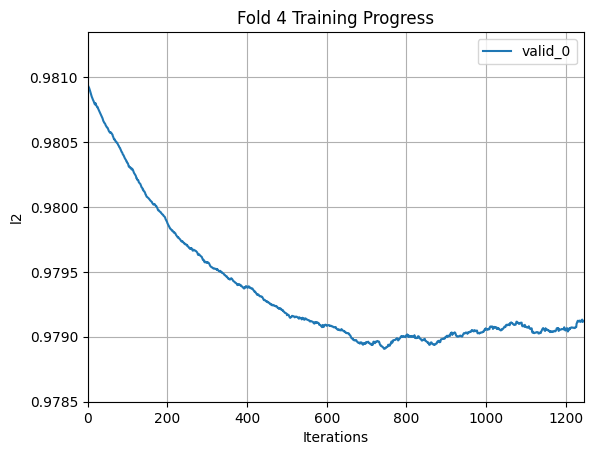

valid ic: 0.05363572494252131
模型最佳迭代次数 = 745

Fold 5/5
Fold 5 验证集日期范围: 2025-02-06 14:25:00 至 2025-07-01 23:59:00
Fold 5 训练集样本数: 154270, 验证集样本数: 38567
Training until validation scores don't improve for 500 rounds
[100]	valid_0's l2: 0.986981
[200]	valid_0's l2: 0.986687
[300]	valid_0's l2: 0.986475
[400]	valid_0's l2: 0.986338
[500]	valid_0's l2: 0.986233
[600]	valid_0's l2: 0.986215
[700]	valid_0's l2: 0.986167
[800]	valid_0's l2: 0.986161
[900]	valid_0's l2: 0.986179
[1000]	valid_0's l2: 0.986233
[1100]	valid_0's l2: 0.986278
[1200]	valid_0's l2: 0.986302
[1300]	valid_0's l2: 0.986405
Early stopping, best iteration is:
[800]	valid_0's l2: 0.986161


<Figure size 1000x600 with 0 Axes>

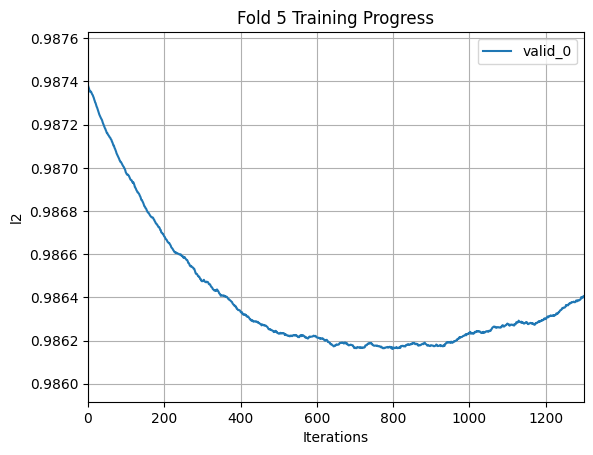

valid ic: 0.033508102782899306
模型最佳迭代次数 = 800
特征重要性已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/importance/2025-07-01_AO_5_feature_importance_reg.csv
特征相关系数表已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/correlation/2025-07-01_AO_5_feature_corr.csv
因子组别表已保存到 /mnt/Data/writable/liaoyuyang/factor_eval_commodity/2025-07-01/group/2025-07-01_AO_5_feature_group.csv
最后两列 Index(['pred_ret', 'hour'], dtype='object')


In [4]:
fac_df = pd.read_feather(f'/mnt/Data/writable/liaoyuyang/factor/{symbol}/all_fac/all_factor.feather').set_index(['datetime']).loc[:train_end_date]
fac_df = config_loader.df_cut_time(fac_df, config_loader.get_instrument_config(symbol)['trading_hours'], 10)

exclude_factors = [
        'datetime', 'instrument',
        ]

factor_col = [x for x in fac_df.columns if x not in exclude_factors]

main_fac_piv = fac_df[factor_col]
rtn_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/data/1min/active/main_{symbol}.csv', index_col=0, parse_dates=['ts']).set_index('ts').reindex(index=fac_df.index)
main_fac_piv['pred_ret'] = rtn_df[f'rtn_{train_label}']
main_fac_piv = main_fac_piv.replace([np.inf, -np.inf], np.nan)
main_fac_piv['hour'] = main_fac_piv.index.hour

main_fac_piv['pred_ret'].hist(bins=100, figsize=(8, 3), alpha=0.7, color='blue')
plt.grid(True, alpha=0.3)
plt.show()

pretrainer = pt.Pretrainer(symbol, main_fac_piv, train_end_date, train_label=train_label)

importance = pretrainer.run_full_pretraining(type_lgb = 'reg')

In [5]:
factor_info = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/{symbol}_single_factor_eval_{train_label}.csv', index_col=0)
importance_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/importance/{train_end_date}_{symbol}_{train_label}_feature_importance_reg.csv')
corr_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/correlation/{train_end_date}_{symbol}_{train_label}_feature_corr.csv', index_col=0)
group_df = pd.read_csv(f'/mnt/Data/writable/liaoyuyang/factor_eval_commodity/{train_end_date}/group/{train_end_date}_{symbol}_{train_label}_feature_group.csv')
factor_to_choose = main_fac_piv.columns[:-1]

factor_filter = FF.FactorFilter(importance_df, corr_df, group_df, factor_info, factor_to_choose)
print([x for x in factor_filter.factor_to_choose if x not in factor_info.index])
params = {
    "info_select_params": {"nan_rate": 0.8, "mode_rate": 0.9},
    "importance_select_by_group_params" : {"cut_num_1": 300, "cut_num_2":200, "same_name_cut": 5}, 
    "corr_select_params": {"feature_num_limit": 300, "corr_limit": 0.9}, 
    "sp_select": {"th":0.5},
    "day_cut": {"num_limit":5},
    "exclude_factors": [
            'datetime', 'instrument',
            'JC1D', 'ZCpriceinterval', 'ptvol5',
            'JC2H'
            ]
}
factor_filter.run_selection(**params)

lst1 = [x for x in factor_filter.factor_to_choose if x.startswith('FAC')]
lst2 = [x for x in factor_filter.factor_to_choose if x.startswith('STK')]
lst3 = [x for x in factor_filter.factor_to_choose if re.match(r'^(_AL|AL_|_AO|AO_|_BC|BC_|_CU|CU_|_NI|NI_|_PB|PB_|_SN|SN_|_ZN|ZN_)', x)]
lst4 = [x for x in factor_filter.factor_to_choose if x not in lst1+lst2+lst3]
len(lst1), len(lst2), len(lst3), len(lst4)

['pred_ret']
特征分布性过滤：
筛选之前因子数量：1871， 筛选之后因子数量：1801

特征重要性过滤： 300 200 	待筛因子个数 1801
无向因子有效个数： 805 有向因子有效个数： 1051
  选择有向特征 215 个，重要性范围: 3374.00 - 72.00
  选择无向特征 145 个，重要性范围: 2642.00 - 170.00

单因子sharpe过滤： 0.5 sp范围-16.171 ~ 13.2599   待筛因子个数 360

特征相关性性过滤： 300     待筛因子个数 299
  选择特征 250 个, 特征最大相关性0.8999698139022598

已挑选日频开盘因子数量： 5 ['day_first4redcorr', 'day_first4greencorr', 'day_first10rev', 'day_first3power', 'day_first10colarrate']

保留日频开盘因子数量： 5 ['day_first4redcorr', 'day_first4greencorr', 'day_first10rev', 'day_first3power', 'day_first10colarrate']

排除指定因子后，剩余特征 248 个


(179, 0, 42, 27)

正在从 /mnt/Data/writable/liaoyuyang/factor/AO/all_fac/all_factor.feather 加载数据...
训练数据加载完成，形状: (192436, 1875)
训练集时间范围: 2023-06-19 09:11:00 至 2025-07-01 00:00:00
[200]	valid_0's rmse: 0.962224
[400]	valid_0's rmse: 0.962111
[600]	valid_0's rmse: 0.962115
[800]	valid_0's rmse: 0.962033
[1000]	valid_0's rmse: 0.961973
[1200]	valid_0's rmse: 0.961909
[1400]	valid_0's rmse: 0.961844
[1600]	valid_0's rmse: 0.961703
[1800]	valid_0's rmse: 0.961666
[2000]	valid_0's rmse: 0.961562
[2200]	valid_0's rmse: 0.961513
[2400]	valid_0's rmse: 0.961432
[2600]	valid_0's rmse: 0.961398
[2800]	valid_0's rmse: 0.96137
[3000]	valid_0's rmse: 0.961332
[3200]	valid_0's rmse: 0.961347
[3400]	valid_0's rmse: 0.961381
[3600]	valid_0's rmse: 0.96137


<Figure size 1000x600 with 0 Axes>

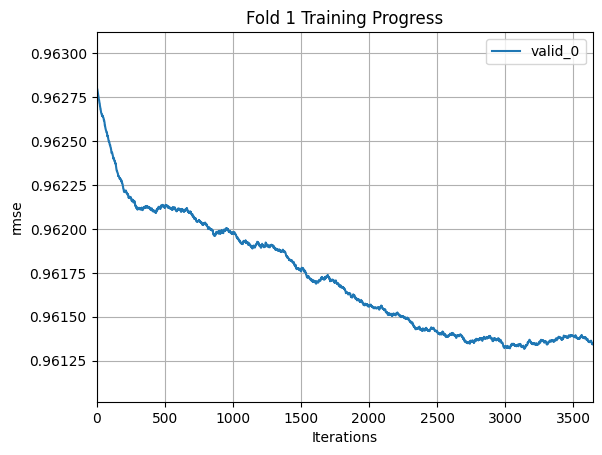

{'train_rmse': np.float64(0.9608996639095845), 'val_rmse': np.float64(0.9983673846144483), 'best_iteration': 3142}
test_corr: 0.0180
[200]	valid_0's rmse: 0.974965
[400]	valid_0's rmse: 0.974346
[600]	valid_0's rmse: 0.974018
[800]	valid_0's rmse: 0.973928
[1000]	valid_0's rmse: 0.973886
[1200]	valid_0's rmse: 0.973876
[1400]	valid_0's rmse: 0.974015
[1600]	valid_0's rmse: 0.974154


<Figure size 1000x600 with 0 Axes>

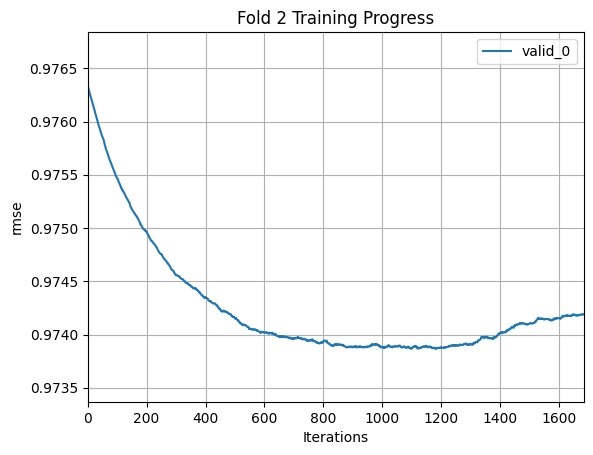

{'train_rmse': np.float64(0.9817046897479856), 'val_rmse': np.float64(0.9974161378123505), 'best_iteration': 1183}
test_corr: 0.0279
[200]	valid_0's rmse: 0.992611
[400]	valid_0's rmse: 0.99246
[600]	valid_0's rmse: 0.992399
[800]	valid_0's rmse: 0.992335
[1000]	valid_0's rmse: 0.992322
[1200]	valid_0's rmse: 0.992367
[1400]	valid_0's rmse: 0.992362


<Figure size 1000x600 with 0 Axes>

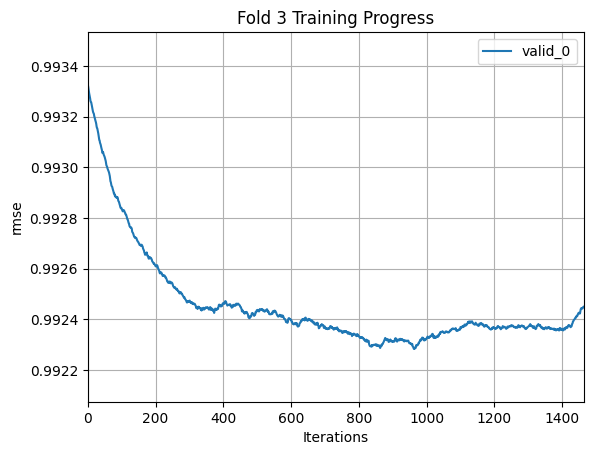

{'train_rmse': np.float64(0.9837588992725104), 'val_rmse': np.float64(0.9989585799026381), 'best_iteration': 964}
test_corr: 0.0322
[200]	valid_0's rmse: 0.989631
[400]	valid_0's rmse: 0.98949
[600]	valid_0's rmse: 0.989505
[800]	valid_0's rmse: 0.989782
[1000]	valid_0's rmse: 0.990152


<Figure size 1000x600 with 0 Axes>

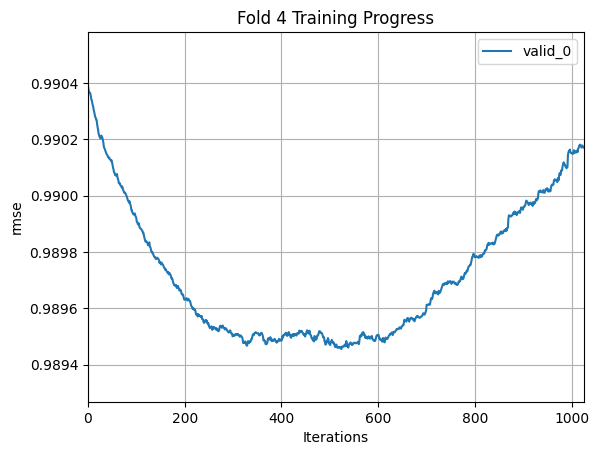

{'train_rmse': np.float64(0.9905650156256954), 'val_rmse': np.float64(0.9991231237947364), 'best_iteration': 525}
test_corr: 0.0249
[200]	valid_0's rmse: 0.993129
[400]	valid_0's rmse: 0.993364
[600]	valid_0's rmse: 0.993636


<Figure size 1000x600 with 0 Axes>

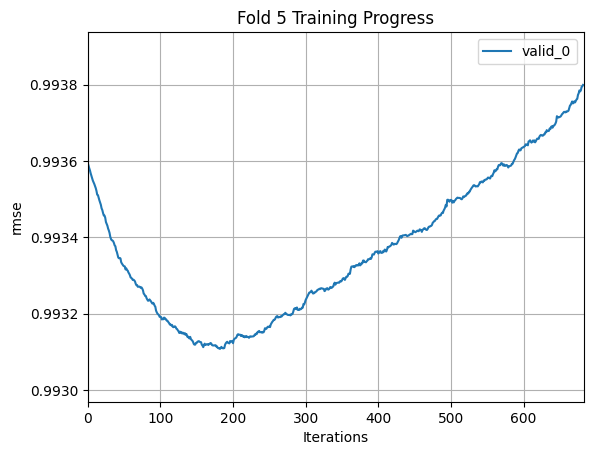

{'train_rmse': np.float64(0.9960736699241804), 'val_rmse': np.float64(0.9996219168597559), 'best_iteration': 183}
test_corr: 0.0316


In [6]:
analyzer = tm.TimeSeriesAnalyzer(
    symbol = symbol,
    factor_col = factor_filter.factor_to_choose,
    train_end_date = train_end_date,
    config_loader = config_loader
)
analyzer.load_and_prepare_data(log_rtn=True, set_category_col=['hour'], label_col=f'rtn_{train_label}', cut=True)
trainer = tm.LGBMTrainer(analyzer)
_ = trainer.train_kfold_v0(custom_params={'verbose':-1}, model_folder_name=folder_name, plot_train=True, n_splits=5)

In [7]:
config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)
config

{'MODEL_DIR': PosixPath('/mnt/Data/writable/liaoyuyang/model/lightgbm/KFoldModel/models/AO_pred5_2025-07-01_v0'),
 'OUTPUT_DIR': '/mnt/Data/writable/liaoyuyang/backtest/results',
 'pic_dir': '/mnt/Data/writable/liaoyuyang/backtest/pic',
 'feature_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/features',
 'pred_label_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/predictions',
 'merged_output_dir': '/mnt/Data/writable/liaoyuyang/backtest/data/merged',
 'start_date': '20180101',
 'end_date': '20260101',
 'ts_col': 'datetime',
 'instrument_col': 'instrument',
 'target_col': 'pred_ret',
 'holding_price_col': 'close',
 'trading_price_col': 'tick6t60avg',
 'pos_col': 'pos',
 'category_col': ['hour'],
 'factor_col': 'factor',
 'filter_dict': {'exclude_night': True},
 'auto_create_dirs': True}

In [8]:
bt = bv.ModelBacktester(train_end_date, config)
bt.load_config(symbol)
bt.window_end = '2027-01-01'
bt.money = 200_000 
bt.fee = 0

bt.load_factor(symbol, end_date=bt.window_end)
bt.load_mktdata(symbol, end_date=bt.window_end)
bt.load_models()
bt.generate_predictions()
pred = bt.combine_models('best_iteration_log_weighted', avg=True)

In [21]:
merged_data = bt.backtest(th1=0.9, th2=0.5, save=False, open_drop=True, holding_bars=10,
                           day=5*465, model_name='best_iteration_log_weighted', v=2
                        )

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-01:00']
使用的交易价格 tick6t60avg


计算持仓表:   0%|          | 0/56420 [00:00<?, ?it/s]

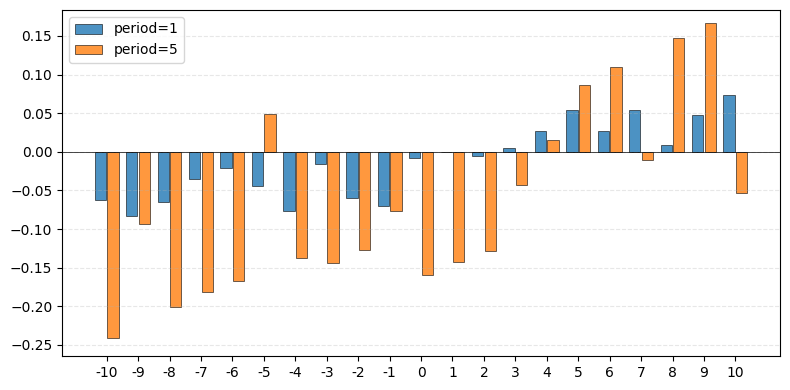

In [22]:
fig = bv.plot_group_bar(merged_data, periods=[1,5], trading_hours=["09:00-11:30", "13:30-15:00", "21:00-23:00"], g=21)

In [23]:
bv.analyze_pos_distribution(merged_data)

,统计值
多头(+1) 数量,11464
空头(-1) 数量,11103
空仓(0) 数量,33855
多头占比,20.32%
空头占比,19.68%
空仓占比,60.00%
交易日数量,123
总收益(非年化%),93.40
总交易次数（开平算一次）,2706
每笔收益(%%),3.45


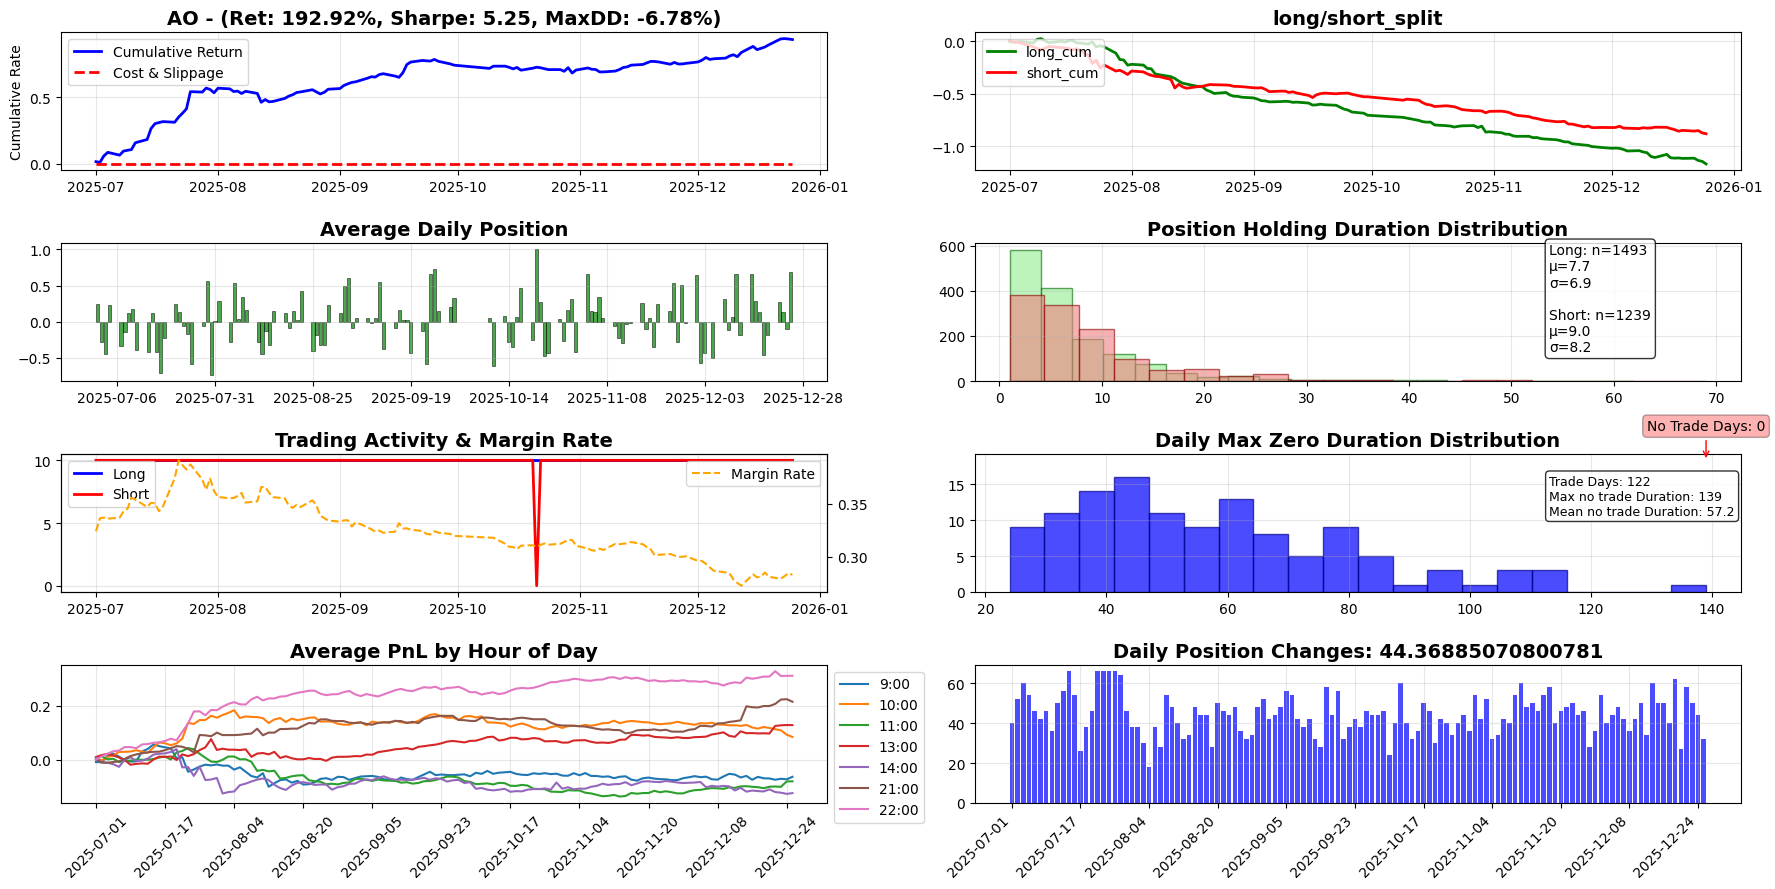

In [24]:
fig = bv.plot_eval(symbol, merged_data, "无")

In [26]:
tvp = TV.TradingVisualizationPager(symbol=symbol, data = merged_data, skip_weekends=True)
tvp.run()

Output()

✅ 交易可视化工具已启动
📈 品种: AO
📅 总交易日数: 122
📊 总数据点: 58926
🎯 使用导航按钮或输入页码进行浏览


In [27]:
bv.plot_yearly_eval(merged_data)